<a href="https://colab.research.google.com/github/Bhumiii27/ML-Labs/blob/main/ML_lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ['KAGGLE_USERNAME']='bhumisolanki27'
os.environ['KAGGLE_KEY']='KGAT_48dffe782818ad1ac760c4b024602f2a'

In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets download shivamb/netflix-shows

Dataset URL: https://www.kaggle.com/datasets/shivamb/netflix-shows
License(s): CC0-1.0
100% 1.34M/1.34M [00:00<00:00, 97.4MB/s]



In [ ]:
#unzipping the file
!unzip -q netflix-shows.zip

In [ ]:
#importing basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#import dataset using pandas
df=pd.read_csv('/content/netflix_titles.csv')

In [ ]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [ ]:
df.shape
#output is always tuple instead of list as it is immutable

(8807, 12)

In [ ]:
df.info()
#rows -> observations
#columns -> features

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
#your dataset should have 0 null/missing values as you can't train your ml
#model on missing values as it requires observations(rows) and features(columns)

In [ ]:
df.isnull()
#outcome is a boolean

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,False,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False
3,False,False,False,True,True,True,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,False,False,False,False,False,False,False,False,False,False,False,False
8803,False,False,False,True,True,True,False,False,False,False,False,False
8804,False,False,False,False,False,False,False,False,False,False,False,False
8805,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
#you delete the entire feature/observation only if 40-50% of the data is missing.
#otherwise put dummy values but make sure it doesn't change the pattern/characteristic of the dataset.

In [ ]:
#imputing the missing value -> unknown
df['director']=df['director'].fillna('Unknown')

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df['cast']=df['cast'].fillna('Unknown')
df['country']=df['country'].fillna('Unknown')
df['date_added']=df['date_added'].fillna('Unknown')

In [ ]:
df['rating'].mode()[0]
#outcome is series

'TV-MA'

In [ ]:
df['rating']=df['rating'].fillna(df['rating'].mode()[0])
df['duration']=df['duration'].fillna(df['duration'].mode()[0])

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

<Axes: xlabel='type', ylabel='count'>

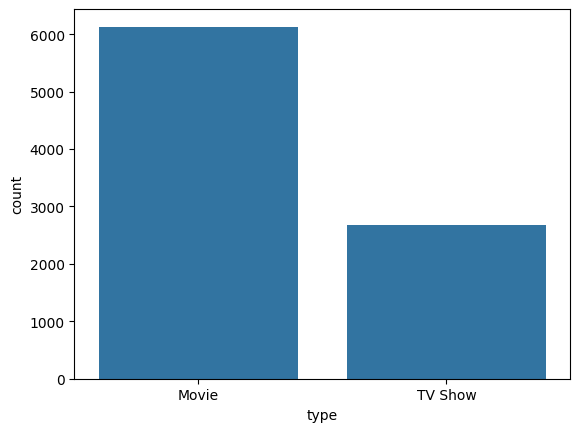

In [ ]:
#Data Visualisation
sns.countplot(x='type', data=df)

In [ ]:
df.director

,director
0,Kirsten Johnson
1,Unknown
2,Julien Leclercq
3,Unknown
4,Unknown
...,...
8802,David Fincher
8803,Unknown
8804,Ruben Fleischer
8805,Peter Hewitt


<Axes: xlabel='director'>

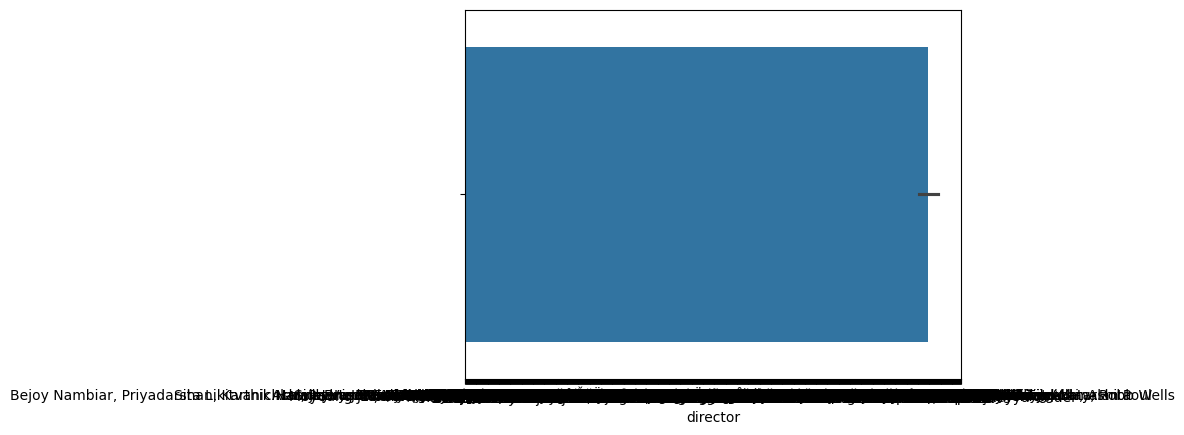

In [ ]:
sns.barplot(x='director', data=df)

[1:] in this code is for removing the unknown category

<Axes: ylabel='director'>

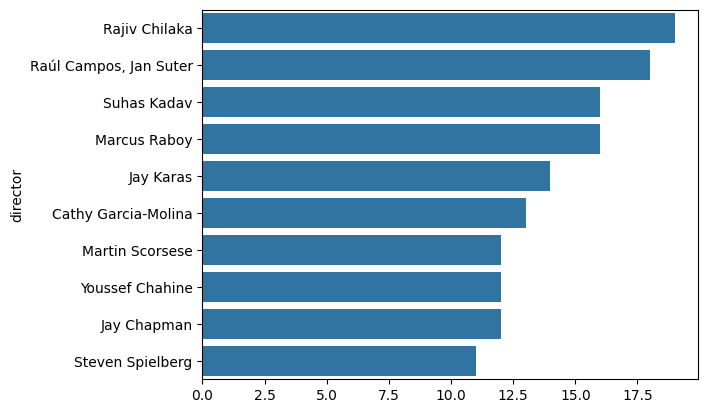

In [ ]:
#Top contributing director
top_director=df['director'].value_counts()[1:].head(10)
sns.barplot(x=top_director.values, y=top_director.index)

In [ ]:
df.cast

,cast
0,Unknown
1,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban..."
2,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi..."
3,Unknown
4,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K..."
...,...
8802,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J..."
8803,Unknown
8804,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ..."
8805,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma..."


find which person has major contribution

<Axes: ylabel='cast'>

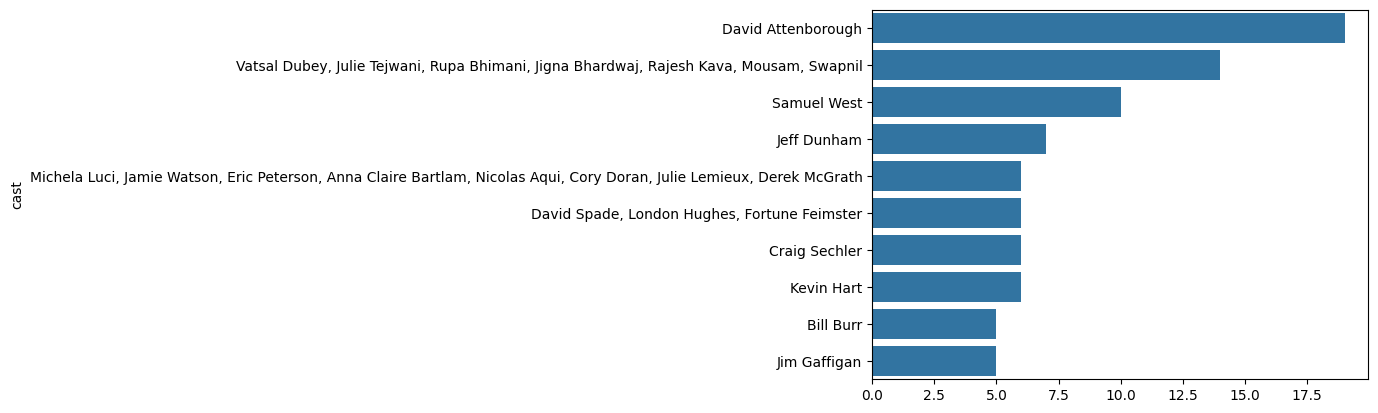

In [ ]:
#Most contributing cast
top_cast=df['cast'].value_counts()[1:].head(10)
sns.barplot(x=top_cast.values, y=top_cast.index)

In [ ]:
df.country

,country
0,United States
1,South Africa
2,Unknown
3,Unknown
4,India
...,...
8802,United States
8803,Unknown
8804,United States
8805,United States


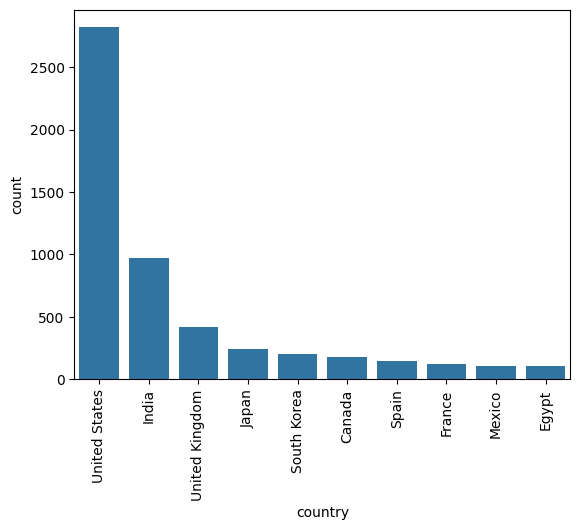

In [ ]:
#Most contributing country
#top_countries=df['country'].value_counts()[:].head(10)
#sns.barplot(x=top_countries.values, y=top_countries.index)
#The above shows bar plot without fn below is inside fn
#.drop('Unknown) is used to drop unknown from middle
sns.countplot(x='country', data=df, order=df['country'].value_counts().drop('Unknown').head(10).index)
plt.xticks(rotation=90)
plt.show()

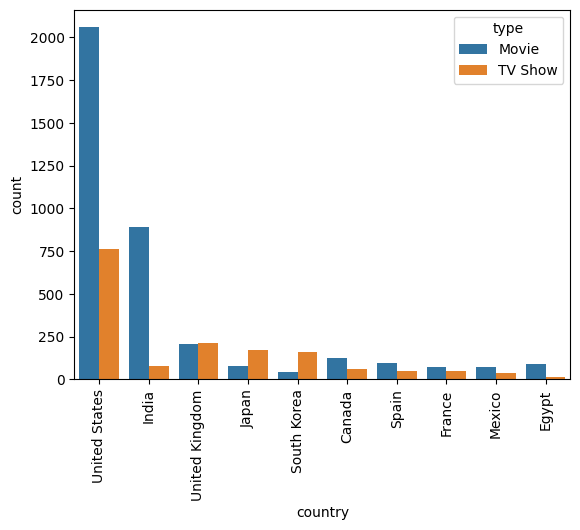

In [ ]:
#same graph but distinguish movies and TV shows for each
sns.countplot(x='country', data=df, order=df['country'].value_counts().drop('Unknown').head(10).index, hue='type')
plt.xticks(rotation=90)
plt.show()